In [7]:
import h5py
import matplotlib.pyplot as plt
from preprocess import ecg_processing_pipeline
import os 
import cv2
import numpy as np 
import glob 


In [8]:
def load_contours_from_hdf5(filepath='contours.h5'):
    """
    Load all contours from HDF5 file back into dictionary format
    """
    contour_dict = {}
    
    with h5py.File(filepath, 'r') as f:
        for img_id in f.keys():
            grp = f[img_id]
            
            contour_dict[img_id] = {
                'contour': grp['contour'][:],  # Load the contour array
                'scale_x': grp.attrs['scale_x'],
                'scale_y': grp.attrs['scale_y'], 
                'half': grp.attrs['half']
            }
    
    return contour_dict

# Usage
contours = load_contours_from_hdf5('contours.h5')

In [9]:
def single_img_output(img_id, data_path=os.path.abspath("../../data/train")):
    value = f"train_{str(img_id).zfill(6)}.png"
    img_path = os.path.join(data_path, value)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)
    output = ecg_processing_pipeline(input_image = img, 
                                contour_data = contours[value.split(".")[0]])
    return output

def fourier_grid_check(proc_img): 
    if len(proc_img.shape) == 3:
        image = cv2.cvtColor(proc_img, cv2.COLOR_BGR2GRAY)
    
    f = np.fft.fft2(image)
    fshift = np.fft.fftshift(f)
    mag = np.abs(fshift)
    
    spec = np.log1p(mag)
    
    return spec

def compute_output(img_ids, 
                data_path=os.path.abspath("../../data/train"), 
                save_processed=False,
                plot=False): 
    height_width_ratios = []
    outputs = {}
    for img_id in img_ids: 
        output = single_img_output(img_id, data_path=data_path)
        if save_processed:
            new_path = os.path.join(data_path, "processed")
            os.makedirs(new_path, exist_ok=True)
            filename = os.path.join(new_path, f"train_{str(img_id).zfill(6)}.png")
            cv2.imwrite(filename, output)
                        
        outputs[f"{img_id}"] = output
        if plot:
            plt.figure()
            plt.imshow(output)
            plt.show()    
            
            plt.figure()
            plt.imshow(fourier_grid_check(output), cmap="inferno")
            
        # width/height ratio
        height_width_ratios.append(output.shape[0]/output.shape[1])
    return outputs, np.array(height_width_ratios)

In [10]:
curated_images = glob.glob(
    os.path.join(
        os.path.abspath("../../data"),
        "for_segmentation",
        "currently_segmented",
        "train_*"
    ))
curated_img_ids = [int(os.path.basename(path).split(".")[0][-6:]) for path in curated_images]

In [11]:
curated_img_ids = [20]

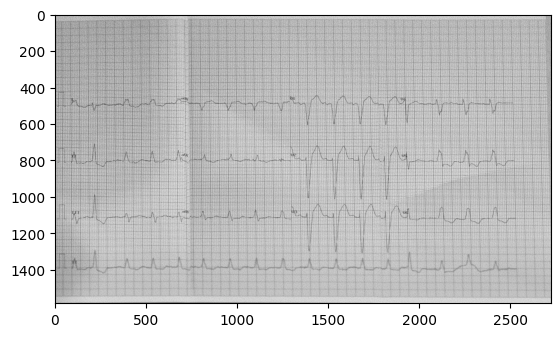

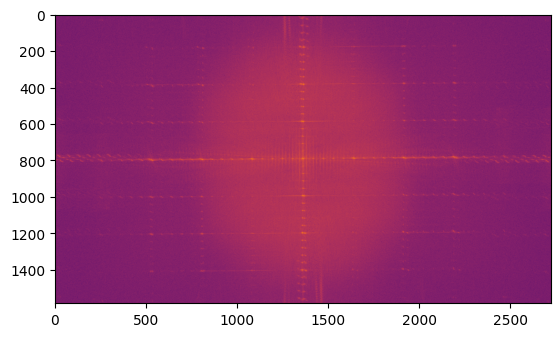

In [12]:
outputs, ratios = compute_output(curated_img_ids,
                                data_path=os.path.join(os.path.abspath("../../data"),
                                                    "train"),
                                save_processed=False,
                                plot=True)